In [10]:
from pydantic import BaseModel, Field
from typing import List, Optional
from selenium import webdriver
from langchain_core.messages import BaseMessage

# 1. 상태 정의
class AgentState(BaseModel):
    """LangGraph 에이전트의 상태를 정의합니다."""
    messages: List[BaseMessage] = Field(description="대화 로그 및 도구 실행 결과를 포함하는 메시지 목록")
    driver: object = Field(description="셀레니움 웹 드라이버 인스턴스", default=None)
    current_url: str = Field(default="", description="현재 웹페이지 URL")
    # query: str = Field(description="사용자의 초기 질문")
    # driver: object = Field(description="셀레니움 웹 드라이버 인스턴스")
    current_url: str = Field(description="현재 웹페이지 URL")
    html_content: str = Field(default="", description="현재 페이지의 HTML 콘텐츠")
    interactive_elements: List[dict] = Field(default=[], description="상호작용 가능한 요소 (링크, 버튼 등) 목록")
    search_result: Optional[str] = Field(default=None, description="사용자 질문에 대한 최종 답변")

    #  Pydantic 모델의 설정을 정의하는 내부 클래스
    # - Pydantic이 자체적으로 검증 규칙을 가지고 있지 않은 임의의 사용자 정의 클래스나 외부 라이브러리 객체에 대해서만 유효성 검사를 완화
    # - selenium.webdriver 인스턴스인 driver 필드는 Pydantic이 알지 못하는 외부 라이브러리 객체
    # - Pydantic은 이 객체의 내부 구조를 검증할 수 없음 -> TypeError 발생
    class Config: 
        arbitrary_types_allowed = True

In [2]:
from langchain_core.tools import tool
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup

# 2. 도구 정의 (Selenium 활용)
class BrowserTools:
    """웹 브라우저와 상호작용하는 도구 모음입니다."""

    def __init__(self):
        self.driver = webdriver.Chrome()
        # self.driver.maximize_window() # 브라우저 화면 최대 크기
        self.driver.set_window_size(1280, 720)
        # self.driver.set_window_size(1920, 1080)
        self.wait = WebDriverWait(self.driver, 10)

    @tool
    def navigate_to(self, url: str):
        """특정 URL로 이동합니다."""
        self.driver.get(url)
        return f"현재 페이지를 {url}로 이동했습니다."

    @tool
    def click_element(self, selector: str):
        """CSS 선택자를 사용하여 요소를 클릭합니다."""
        try:
            element = self.wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, selector)))
            element.click()
            return f"요소 {selector}를 클릭했습니다."
        except Exception as e:
            return f"요소 {selector}를 클릭하는 데 실패했습니다: {e}"

    @tool
    def press_key(self, selector: str, key: str) -> str:
        """주어진 CSS 셀렉터에 해당하는 웹 요소에 특정 키를 누릅니다."""
        try:
            if key.upper() != "ENTER":
                return f"오류: 지원하지 않는 키 '{key}'입니다. 'ENTER'만 사용할 수 있습니다."

            # WebDriverWait를 사용하여 안정성 확보
            element = self.wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, selector)))
            element.send_keys(Keys.ENTER)
            return f"'{selector}' 요소에 '{key}' 키를 성공적으로 눌렀습니다."
        except Exception as e:
            return f"키 입력 실패: {e}"
    
    @tool
    def input_text(self, selector: str, text: str) -> str:
        """CSS 선택자를 사용하여 요소에 텍스트를 입력합니다."""
        try:
            element = self.wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, selector)))
            element.clear()  # 기존 텍스트 삭제
            element.send_keys(text)
            return f"요소 {selector}에 '{text}'를 입력했습니다."
        except Exception as e:
            return f"요소 {selector}에 텍스트를 입력하는 데 실패했습니다: {e}"      

    @tool
    def get_page_content(self):
        """현재 페이지의 HTML 콘텐츠를 반환합니다."""
        html_content = self.driver.page_source
        soup = BeautifulSoup(html_content, "html.parser")
        # 스크립트, 스타일 태그 제거하여 내용만 추출
        for script in soup(["script", "style"]):
            script.decompose()
        text = soup.get_text()
        lines = (line.strip() for line in text.splitlines())
        chunks = (phrase.strip() for line in lines for phrase in line.split("  "))
        text = '\n'.join(chunk for chunk in chunks if chunk)
        return text
    
    # get_page_content와 별도로 또는 내부에서 실행할 헬퍼 함수
    def get_interactive_elements(self):
        soup = BeautifulSoup(self.driver.page_source, "html.parser")
        elements = []
        # 링크, 버튼, 입력창 등 추출 (예시)
        for tag in soup.find_all(['a', 'button', 'input']):
            elements.append({
                "tag": tag.name,
                "text": tag.get_text(strip=True),
                "attributes": {"id": tag.get("id"), "class": tag.get("class")}
            })
        return elements

    def close(self):
        self.driver.quit()

In [5]:
# LLM과 에이전트 설정
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

browser_tools = BrowserTools()

tools = [
    browser_tools.navigate_to, 
    browser_tools.click_element, 
    browser_tools.press_key,
    browser_tools.input_text,
    browser_tools.get_page_content
]

llm_with_tools = model.bind_tools(tools)

In [14]:
from langchain_core.messages import HumanMessage
from typing import Literal

def agent_node(state: AgentState) -> dict:
    """LLM이 다음 행동을 결정하는 노드. 변경된 상태를 dict로 반환합니다."""
    # 상태 업데이트: 현재 URL과 페이지 콘텐츠를 가져옴
    current_url = state['driver'].current_url
    html_content = BrowserTools(state['driver']).get_page_content.invoke({})

    # LLM 호출
    response = llm_with_tools.invoke([
        HumanMessage(content=state['query']),
        HumanMessage(content=f"현재 페이지 URL: {current_url}"),
        HumanMessage(content=f"현재 페이지 내용의 일부: {html_content[:3000]}"),
    ] + state['messages'])
    
    # 변경된 정보만 사전 형태로 반환
    return {
        "messages": state['messages'] + [response],
        "current_url": current_url,
        "html_content": html_content
    }

def call_tool_node(state: AgentState) -> dict:
    """에이전트의 결정에 따라 도구를 실행하는 노드. 추가된 메시지를 dict로 반환합니다."""
    browser_tools = BrowserTools(state['driver'])
    
    new_messages = []
    last_message = state['messages'][-1]
    for tool_call in last_message.tool_calls:
        tool_name = tool_call['name']
        tool_args = tool_call['args']
        
        tool_function = getattr(browser_tools, tool_name)
        
        tool_output = tool_function.invoke(tool_args)
        new_messages.append(
            HumanMessage(content=f"도구 '{tool_name}' 실행 결과: {tool_output}")
        )
    
    # 추가된 메시지만 반환
    return {"messages": state['messages'] + new_messages}

def human_input_node(state: AgentState) -> dict:
    """사용자로부터 직접 입력을 받는 노드. 추가된 메시지/결과를 dict로 반환합니다."""
    print("\n--- 에이전트가 질문합니다 ---")
    print(state['messages'][-1].content)
    human_input = input("답변을 입력하세요 (작업을 끝내려면 'exit' 입력): ")
    print("----------------------------\n")

    if human_input.lower() == 'exit':
        final_message = "사용자에 의해 작업이 종료되었습니다."
        return {
            "messages": state['messages'] + [HumanMessage(content="사용자가 작업을 종료했습니다.")],
            "search_result": final_message
        }
    else:
        return {"messages": state['messages'] + [HumanMessage(content=human_input)]}

def final_answer_node(state: AgentState) -> dict:
    """최종 답변을 생성하는 노드. 최종 결과를 dict로 반환합니다."""
    if state.get('search_result'):
        return {"search_result": state['search_result']}

    final_prompt = f"사용자의 질문에 대한 최종 답변을 생성해줘: {state['query']}\n\n지금까지의 대화 내용과 수집된 정보를 요약해줘:\n{state['messages']}"
    final_response = model.invoke(final_prompt)
    
    return {"search_result": final_response.content}

# * 수정
# 수정된 그래프 구조
def check_response(state: AgentState) -> Literal["call_tool", "human_input", "final_answer"]:
    """LLM 응답에 따라 워크플로우를 분기하는 조건부 노드."""
    last_message = state.messages[-1]
    
    # 1. LLM 응답에 도구 호출이 포함된 경우
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return "call_tool"
    
    # 2. LLM 응답에 도구 호출이 없고, 'search_result'가 이미 존재하는 경우
    # 이 조건은 최종 답변을 생성하는 노드에서만 만족.
    if state.search_result:
        return "final_answer"
        
    # 3. 그 외 모든 경우 (도구 호출이 없는 텍스트 응답)
    # Human-in-the-loop를 위해 human_input으로 보냄.
    # LLM이 직접 답변을 생성하지 않고, 추가 정보가 필요한 상황에 해당.
    return "human_input"

In [15]:
from langgraph.graph import StateGraph, END

# StateGraph에 AgentState를 전달하여 워크플로우 객체 생성
workflow = StateGraph(AgentState)

# 노드 추가
workflow.add_node("agent", agent_node)
workflow.add_node("call_tool", call_tool_node)
workflow.add_node("human_input", human_input_node)
workflow.add_node("final_answer", final_answer_node)

# 진입점(Entry Point) 설정
workflow.set_entry_point("agent")

# 엣지(Edge) 연결
workflow.add_conditional_edges(
    "agent",
    check_response,
    {
        "call_tool": "call_tool",
        "human_input": "human_input",
        "final_answer": "final_answer",
    }
)
workflow.add_edge("call_tool", "agent")
workflow.add_edge("human_input", "agent")
workflow.add_edge("final_answer", END) # final_answer 노드 이후에는 워크플로우 종료

# 그래프 컴파일
app = workflow.compile()

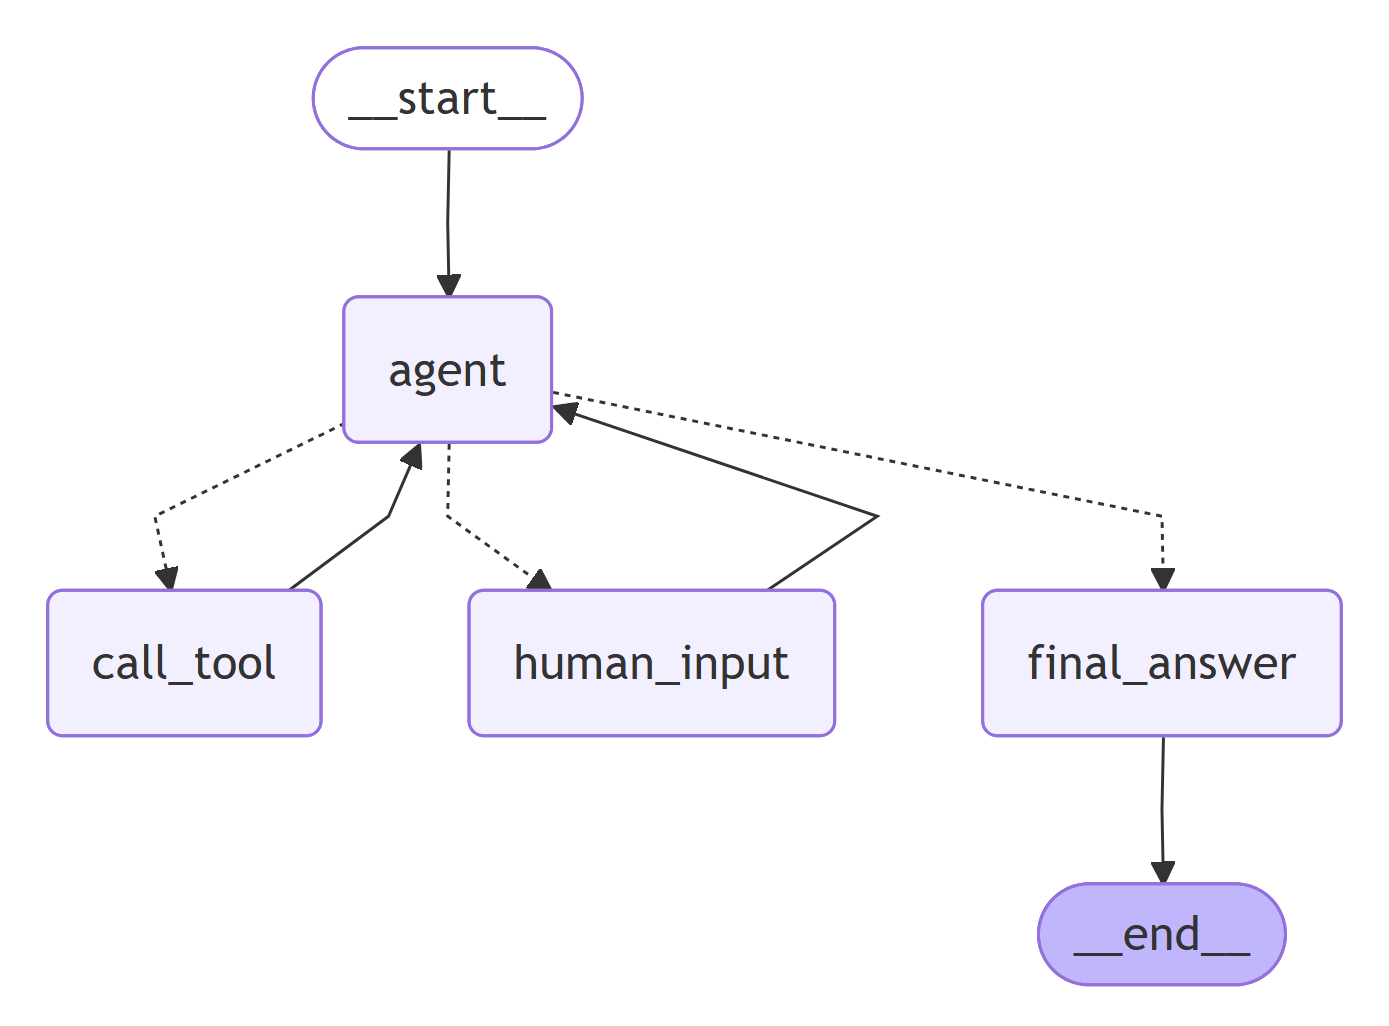

In [17]:
# 파일을 열고 `_render_mermaid_using_pyppeteer` 함수 내부에 있는 `pyppeteer.launch()` 호출 부분을 찾아 `executablePath` 인자를 추가한다.
# browser = await launch(executablePath=r'C:\Program Files\Google\Chrome\Application\chrome.exe')
import nest_asyncio
from IPython.display import display, Image
from langchain_core.runnables.graph_mermaid import MermaidDrawMethod

# 1. 비동기 이벤트 루프 중첩 오류 해결
nest_asyncio.apply()

# 2. (라이브러리 파일 수정 후) 그래프 시각화
display(Image(app.get_graph(xray=True).draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER)))

In [16]:
# 사용자 질문 정의
query = "www.naver.com으로 이동한 후 '환율'을 검색창에 입력한 후 검색을 진행해줘"

# Selenium 드라이버 초기화
driver = webdriver.Chrome()
driver.set_window_size(1280, 720)

# 초기 상태 정의
initial_state = AgentState(
    query=query,
    messages=[],
    driver=driver,
    current_url=""
)

try:
    # 워크플로우 실행 및 스트리밍 출력
    print(f"🚀 에이전트 작업을 시작합니다. 질문: {query}")
    for event in app.stream(initial_state):
        # stream()은 각 노드가 실행될 때마다 해당 노드의 이름과 출력 상태를 반환합니다.
        node_name, output_state = next(iter(event.items()))
        print(f"\n--- 현재 노드: {node_name} ---")
        if 'messages' in output_state:
            # 마지막 메시지(가장 최근 이벤트)만 출력하여 진행 상황 확인
            print(f"메시지: {output_state['messages'][-1].content}")
        print("---------------------------------")
    
    # 최종 결과 출력
    final_state = event[node_name]
    print("\n✅ 최종 작업 결과:")
    print(final_state.get("search_result", "최종 결과가 없습니다."))

except Exception as e:
    print(f"\n❌ 오류가 발생했습니다: {e}")
finally:
    # 모든 작업이 끝나면 브라우저 종료
    print("\n👋 브라우저를 종료합니다.")
    driver.quit()

🚀 에이전트 작업을 시작합니다. 질문: www.naver.com으로 이동한 후 '환율'을 검색창에 입력한 후 검색을 진행해줘

❌ 오류가 발생했습니다: 'AgentState' object is not subscriptable

👋 브라우저를 종료합니다.
